# Lesson 01.5 workbook — build the filters

The run-through showed the filters working. This workbook builds them: whole-image correlation, convolution from a flip, and an original kernel design.

## Setup

The same photo, patch, and kernels as the run-through, plus a results folder for the workbook.

Results directory: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-01-5-workbook
OpenCV: 5.0.0


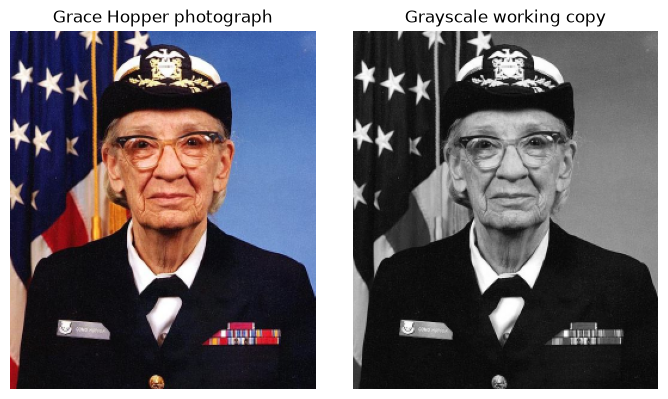

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-01-5-workbook\00-source-photo.png


WindowsPath('C:/Users/Adity/Downloads/Official-Website-portfolio/results/lesson-01-5-workbook/00-source-photo.png')

In [1]:
from pathlib import Path

import cv2
from matplotlib import cbook
import matplotlib.pyplot as plt
import numpy as np


def find_repository_root(start):
    current = Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / ".git").exists():
            return candidate
    raise RuntimeError("Run this notebook from inside the assigned repository")


def plot_image(axis, image, title, display="gray"):
    image_array = np.asarray(image)
    if display == "rgb":
        axis.imshow(image_array)
    elif display == "signed":
        scale = max(float(np.percentile(np.abs(image_array), 99)), 1.0)
        axis.imshow(image_array, cmap="coolwarm", vmin=-scale, vmax=scale)
    elif display == "change":
        upper = max(float(np.percentile(image_array, 99)), 1.0)
        axis.imshow(image_array, cmap="magma", vmin=0, vmax=upper)
    else:
        axis.imshow(image_array, cmap="gray", vmin=0, vmax=255)
    axis.set_title(title)
    axis.axis("off")


def plot_kernel(axis, kernel, title):
    kernel_array = np.asarray(kernel, dtype=np.float32)
    scale = max(float(np.abs(kernel_array).max()), 1.0)
    axis.imshow(kernel_array, cmap="coolwarm", vmin=-scale, vmax=scale)
    for row in range(kernel_array.shape[0]):
        for column in range(kernel_array.shape[1]):
            axis.text(
                column, row, f"{kernel_array[row, column]:g}",
                ha="center", va="center", fontsize=11,
            )
    axis.set_title(title)
    axis.axis("off")


def save_figure(figure, filename):
    output_path = RESULTS_DIR / filename
    figure.tight_layout()
    figure.savefig(output_path, dpi=110, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)
    return output_path


REPO_ROOT = find_repository_root(Path.cwd())
RESULTS_DIR = REPO_ROOT / "results" / "lesson-01-5-workbook"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

PHOTO_PATH = Path(cbook.get_sample_data("grace_hopper.jpg", asfileobj=False))
photo_bgr = cv2.imread(str(PHOTO_PATH), cv2.IMREAD_COLOR)
if photo_bgr is None:
    raise RuntimeError(f"OpenCV could not read the sample photo: {PHOTO_PATH}")
photo_bgr = cv2.resize(photo_bgr, (256, 300), interpolation=cv2.INTER_AREA)
photo_rgb = cv2.cvtColor(photo_bgr, cv2.COLOR_BGR2RGB)
photo_gray = cv2.cvtColor(photo_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32)

input_patch = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 9]], dtype=np.float32)
asymmetric_kernel = np.array(
    [[1, 2, 0], [0, 0, 0], [0, -1, -2]], dtype=np.float32
)
symmetric_kernel = np.array(
    [[0, 1, 0], [1, -4, 1], [0, 1, 0]], dtype=np.float32
)

print("Results directory:", RESULTS_DIR)
print("OpenCV:", cv2.__version__)

figure, axes = plt.subplots(1, 2, figsize=(7, 4))
plot_image(axes[0], photo_rgb, "Grace Hopper photograph", display="rgb")
plot_image(axes[1], photo_gray, "Grayscale working copy")
save_figure(figure, "00-source-photo.png")

## Exercise 1 — change one coefficient and predict

Copy the run-through kernel and change exactly one coefficient. Work out the new correlation on paper first; the check compares the paper number to the measured one. If the two disagree, the paper math is where to look.

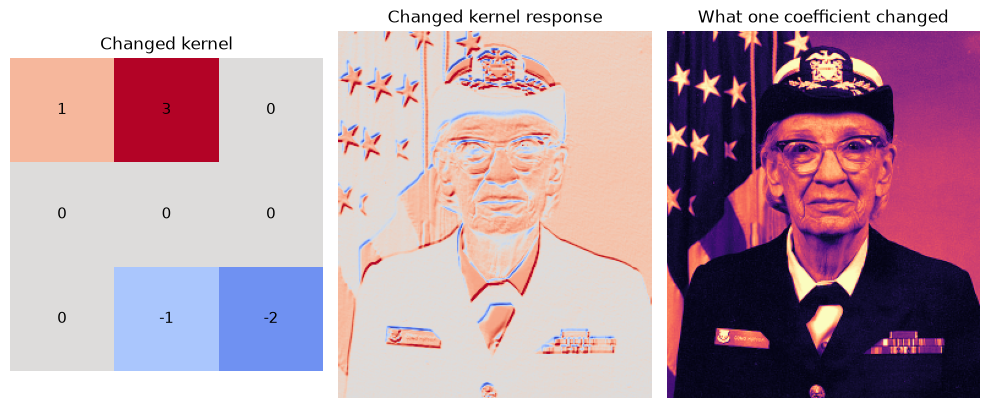

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-01-5-workbook\01-one-coefficient.png
PASS — predicted and measured: -19.0


In [5]:
my_kernel = asymmetric_kernel.copy()
my_kernel[0,1] = 3
my_predicted_correlation = -19



if my_predicted_correlation is None:
    raise RuntimeError("Change a coefficient and record the predicted correlation")
if np.array_equal(my_kernel, asymmetric_kernel):
    raise RuntimeError("my_kernel still equals the run-through kernel — change one coefficient")
changed = int((my_kernel != asymmetric_kernel).sum())
assert changed == 1, f"change exactly one coefficient, not {changed}"

measured = float((input_patch * my_kernel).sum())
assert np.isclose(measured, my_predicted_correlation), (
    f"predicted {my_predicted_correlation}, measured {measured} — redo the paper math"
)

assigned_response = cv2.filter2D(
    photo_gray, cv2.CV_32F, asymmetric_kernel,
    borderType=cv2.BORDER_REFLECT_101,
)
changed_response = cv2.filter2D(
    photo_gray, cv2.CV_32F, my_kernel,
    borderType=cv2.BORDER_REFLECT_101,
)
figure, axes = plt.subplots(1, 3, figsize=(10, 4))
plot_kernel(axes[0], my_kernel, "Changed kernel")
plot_image(
    axes[1], changed_response, "Changed kernel response", display="signed"
)
plot_image(
    axes[2],
    np.abs(changed_response - assigned_response),
    "What one coefficient changed",
    display="change",
)
save_figure(figure, "01-one-coefficient.png")
print("PASS — predicted and measured:", measured)

## Exercise 2 — correlation over the whole image

`correlate_at` handled a single patch. `correlate_image` does the whole image: pad with `np.pad`, slide the window across every pixel, multiply-and-add at each stop, keep the input shape. The checks compare the output to `filter2D` for both border rules.

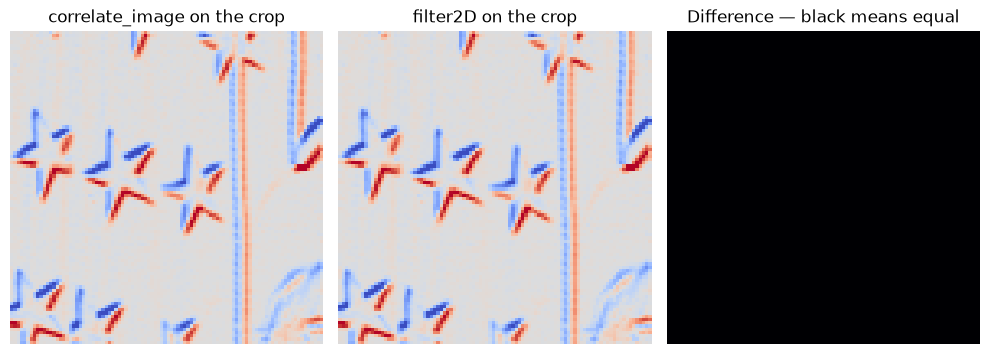

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-01-5-workbook\02-matches-opencv.png
PASS — correlate_image matches filter2D for both border rules


In [7]:
def correlate_image(image, kernel, mode="reflect"):
    image_array = np.asarray(image, dtype=np.float32)
    kernel_array = np.asarray(kernel, dtype=np.float32)
    kh, kw = kernel_array.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(image_array, ((ph, ph), (pw, pw)), mode=mode)
    h, w = image_array.shape
    output = np.zeros((h, w), dtype=np.float32)
    for i in range(h):
        for j in range(w):
            window = padded[i:i+kh, j:j+kw]
            output[i, j] = (window * kernel_array).sum()
    
    return output




crop = photo_gray[:96, :96]
border_pairs = {
    "constant": cv2.BORDER_CONSTANT,
    "reflect": cv2.BORDER_REFLECT_101,
}
for mode, border in border_pairs.items():
    mine = correlate_image(crop, asymmetric_kernel, mode=mode)
    reference = cv2.filter2D(
        crop, cv2.CV_32F, asymmetric_kernel, borderType=border
    )
    assert mine.shape == crop.shape, "output must keep the input shape"
    assert mine.dtype == np.float32, "output must stay float32"
    assert np.allclose(mine, reference, atol=1e-3), (
        f"{mode} mode disagrees with filter2D"
    )

mine_crop = correlate_image(crop, asymmetric_kernel, mode="reflect")
reference_crop = cv2.filter2D(
    crop, cv2.CV_32F, asymmetric_kernel,
    borderType=cv2.BORDER_REFLECT_101,
)
figure, axes = plt.subplots(1, 3, figsize=(10, 4))
plot_image(axes[0], mine_crop, "correlate_image on the crop", display="signed")
plot_image(axes[1], reference_crop, "filter2D on the crop", display="signed")
plot_image(
    axes[2],
    np.abs(mine_crop - reference_crop),
    "Difference — black means equal",
    display="change",
)
save_figure(figure, "02-matches-opencv.png")
print("PASS — correlate_image matches filter2D for both border rules")

Once the checks pass, the next cell runs the finished filter on the whole photo.

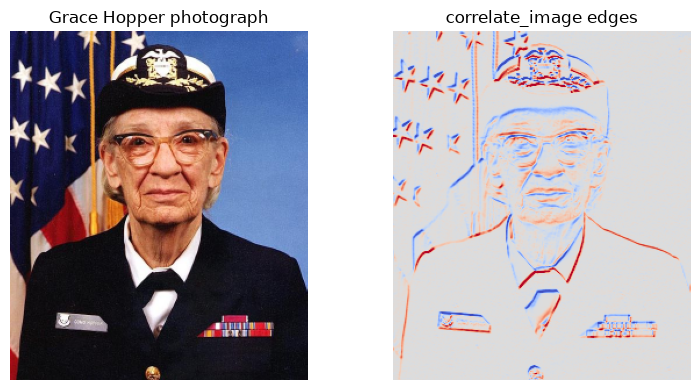

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-01-5-workbook\03-correlate-image.png


WindowsPath('C:/Users/Adity/Downloads/Official-Website-portfolio/results/lesson-01-5-workbook/03-correlate-image.png')

In [8]:
edge_response = correlate_image(photo_gray, asymmetric_kernel, mode="reflect")

figure, axes = plt.subplots(1, 2, figsize=(8, 4))
plot_image(axes[0], photo_rgb, "Grace Hopper photograph", display="rgb")
plot_image(axes[1], edge_response, "correlate_image edges", display="signed")
save_figure(figure, "03-correlate-image.png")

## Exercise 3 — convolution from correlation

Convolution is two lines: flip the kernel, call `correlate_image`. The checks include the hidden-flip trap from the run-through — a symmetric kernel cannot tell the difference — so the flip has to really be there.

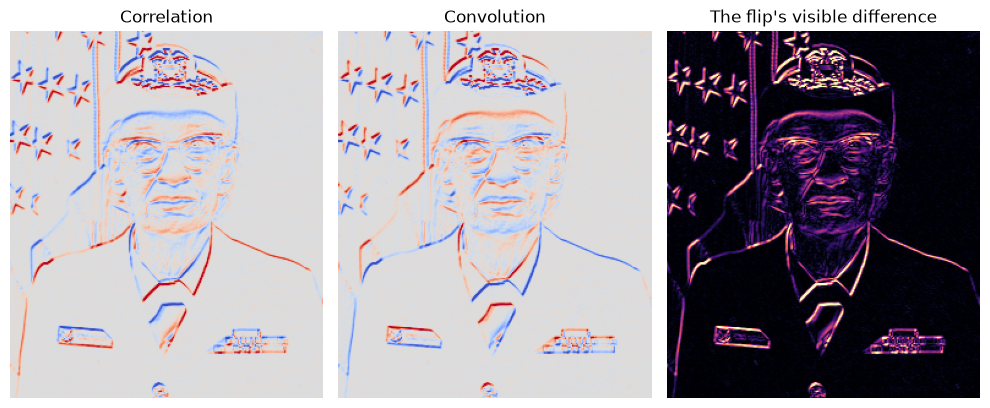

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-01-5-workbook\04-flip-direction.png
PASS — convolve_image matches the flip rule


In [9]:
def convolve_image(image, kernel, mode="reflect"):
    return correlate_image(image, np.flip(kernel, axis=(0, 1)), mode=mode)



conv = convolve_image(crop, asymmetric_kernel)
corr_flipped = correlate_image(crop, np.flip(asymmetric_kernel, axis=(0, 1)))
assert np.allclose(conv, corr_flipped), "convolution must equal correlation of the flip"
assert not np.allclose(conv, correlate_image(crop, asymmetric_kernel)), (
    "convolve_image never flips the kernel"
)
assert np.allclose(
    convolve_image(crop, symmetric_kernel),
    correlate_image(crop, symmetric_kernel),
), "a symmetric kernel must give identical results"

correlation_full = correlate_image(photo_gray, asymmetric_kernel)
convolution_full = convolve_image(photo_gray, asymmetric_kernel)
figure, axes = plt.subplots(1, 3, figsize=(10, 4))
plot_image(axes[0], correlation_full, "Correlation", display="signed")
plot_image(axes[1], convolution_full, "Convolution", display="signed")
plot_image(
    axes[2],
    np.abs(correlation_full - convolution_full),
    "The flip's visible difference",
    display="change",
)
save_figure(figure, "04-flip-direction.png")
print("PASS — convolve_image matches the flip rule")

## Open problem — design a kernel

Design a 3×3 kernel with a visible effect — engraving, motion smear, outline, glow, anything not already in the lesson. Apply it with `correlate_image` and explain in `my_kernel_story` why the coefficients produce the effect. There is no single right answer.

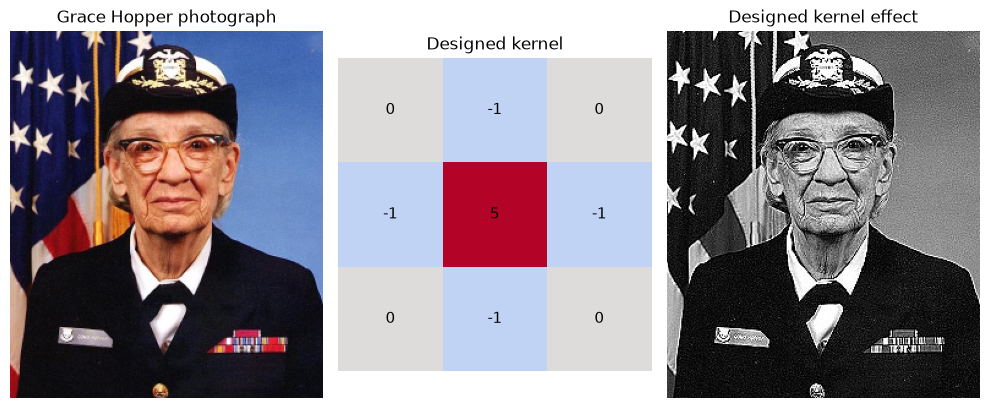

Saved: C:\Users\Adity\Downloads\Official-Website-portfolio\results\lesson-01-5-workbook\05-designed-kernel.png
The center pixel is multiplied by a coefficient of 5-this emphasizes its value, while the neighbors are multiplied by -1, creating a center-focused filter. This sharpens the image by emphasizing pixels and making their neighbors darker, and each subsequent cycle keeps the image's identity while making edges clearer and more visible.


In [11]:
my_design = [[0, -1, 0], [-1, 5, -1], [0, -1, 0]]
my_kernel_story = "The center pixel is multiplied by a coefficient of 5-this emphasizes its value, while the neighbors are multiplied by -1, creating a center-focused filter. This sharpens the image by emphasizing pixels and making their neighbors darker, and each subsequent cycle keeps the image's identity while making edges clearer and more visible."


if my_design is None or not my_kernel_story.strip():
    raise RuntimeError("Design a kernel and write my_kernel_story first")
my_design = np.asarray(my_design, dtype=np.float32)
assert my_design.shape == (3, 3), "keep the design 3×3"
lesson_kernels = (
    np.ones((3, 3), dtype=np.float32) / 9.0,
    asymmetric_kernel,
    symmetric_kernel,
    np.array([[-2, -1, 0], [-1, 0, 1], [0, 1, 2]], dtype=np.float32),
)
assert not any(
    np.allclose(my_design, k) or np.allclose(my_design, np.flip(k, axis=(0, 1)))
    for k in lesson_kernels
), "the kernel must not be one from the lesson"
assert len(my_kernel_story.split()) >= 20, "explain the design in a few sentences"

my_effect = correlate_image(photo_gray, my_design, mode="reflect")
display_mode = "signed" if abs(float(my_design.sum())) < 1e-3 else "gray"
shown = my_effect if display_mode == "signed" else np.clip(my_effect, 0, 255)

figure, axes = plt.subplots(1, 3, figsize=(10, 4))
plot_image(axes[0], photo_rgb, "Grace Hopper photograph", display="rgb")
plot_kernel(axes[1], my_design, "Designed kernel")
plot_image(axes[2], shown, "Designed kernel effect", display=display_mode)
save_figure(figure, "05-designed-kernel.png")
print(my_kernel_story)

## Questions

1. Where does the Exercise 2 loop spend its time, and why is `filter2D` so
   much faster? The Python for loop runs in interpreted bytecode — millions of individual Python instructions for slicing, multiplying, and summing. filter2D is compiled C++ using SIMD instructions, multi-threading, and cache-friendly memory access. The same math runs 100-1000× faster in native machine code, as C++ compiles to it.
2. Which border rule suits a photo with a bright sky along the
   top edge, and why? BORDER_REFLECT_101 (reflect). A bright sky at the top edge gets mirrored back as bright pixels — the filter sees more sky and the border stays bright. BORDER_CONSTANT would fill with zeros, dragging the top edge toward black as the kernel mixes bright sky with dark padding-not what we want.
3. What has to change in the Exercise 2 code to support a 5×5 kernel? Nothing — the code already uses kh // 2 and kw // 2 to compute pad width from the kernel shape. A 5×5 kernel gives ph=2, pw=2, so np.pad adds 2 pixels on each side and the window becomes padded[i:i+5, j:j+5]. The same loop works for any odd-sized kernel, since integer division leads to a remainder, which is our target pixel.

Commit the executed workbook and `results/lesson-01-5-workbook/`, then push. The answer key is released tonight; only work pushed before the release counts.

References: [OpenCV image filtering](https://docs.opencv.org/5.0/main_modules/imgproc_filter.html) · [`numpy.pad`](https://numpy.org/doc/stable/reference/generated/numpy.pad.html)